In [1]:
pip install --upgrade torch ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3

In [2]:
from ultralytics import YOLO
from ultralytics.engine.model import Model
import os, pandas, numpy, cv2, shutil
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
if os.path.exists(f'runs') == True:
	shutil.rmtree('runs')

In [4]:
CLASSES = ['cheerios', 'soup']

yaml_content = f"""
train: /kaggle/input/multi-class-object-detection-challenge/Starter_Dataset/train/images
val: /kaggle/input/multi-class-object-detection-challenge/Starter_Dataset/val/images

nc: {len(CLASSES)}
names: {CLASSES}
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created!")

dataset.yaml created!


In [5]:
import torch.nn.init as init

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.BatchNorm2d):
            init.normal_(m.weight, 1e-3, 0.02)
            init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            init.xavier_uniform_(m.weight)
            if m.bias is not None:
                init.constant_(m.bias, 0)


class AGLU(nn.Module):
    def __init__(self, device=None, dtype=None) -> None:
        super().__init__()
        self.act = nn.Softplus(beta=-1.0)
        self.lambd = nn.Parameter(nn.init.uniform_(torch.empty(1, device=device, dtype=dtype)))
        self.kappa = nn.Parameter(nn.init.uniform_(torch.empty(1, device=device, dtype=dtype)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lam = torch.clamp(self.lambd, min=0.0001)
        return torch.exp((1 / lam) * self.act((self.kappa * x) - torch.log(lam)))

In [6]:
model_yaml = f"""
nc: 80 
scales: 
    m: [0.50, 1.00, 512]
    
activation: nn.SiLU(inplace=True)

backbone:
  - [-1, 1, Focus, [64]]
  - [-1, 1, Focus, [128]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Focus, [256]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Focus, [512]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Focus, [1024]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]

  - [-1, 1, Focus, [256]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, Focus, [512]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]

  - [[16, 19, 22], 1, Detect, [nc]]
"""

with open("model.yaml", "w") as f:
    f.write(model_yaml)

In [7]:
model = YOLO("model.yaml")
model.model.apply(initialize_weights)

WARNING ⚠️ no model scale passed. Assuming scale='m'.


DetectionModel(
  (model): Sequential(
    (0): Focus(
      (conv): Conv(
        (conv): Conv2d(12, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    )
    (1): Focus(
      (conv): Conv(
        (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=Tru

In [8]:
model.train(data='/kaggle/working/dataset.yaml',
            batch=16,
            imgsz=512,
            optimizer="SGD",
            lr0=0.002,
            lrf=0.0001,
            weight_decay=0.0001,
            dropout=0.3,
            dfl=1.00,
            cos_lr=True,
            patience=100,
            save_period=10,
            exist_ok=True,
            plots=True,
            augment=True,
            mosaic=1.0,
            mixup=0.25,
            cutmix=0.25,
            copy_paste=0.05,
            close_mosaic=10,
            hsv_h=0.05, hsv_s=1.0, hsv_v=0.75,
            flipud=0.1, fliplr=0.6,
            translate=0.1, scale=0.6, shear=0.02,
            warmup_epochs=5, warmup_momentum=1,
            workers=4,
            conf=0.25, iou=0.5,
            device=[-1, -1])

valid_results = model.val()
print(valid_results)

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0, 1]
Ultralytics 8.3.170 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                        CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=0.25, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.25, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.0, dnn=False, dropout=0.3, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.6, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.05, hsv_s=1.0, hsv_v=0.75, imgsz=512, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.25, mode=train, model=model.yaml, 

100%|██████████| 755k/755k [00:00<00:00, 23.5MB/s]


Overriding model.yaml nc=80 with nc=2
WARNING ⚠️ no model scale passed. Assuming scale='m'.
activation: nn.SiLU(inplace=True)

                   from  n    params  module                                       arguments                     
  0                  -1  1       896  ultralytics.nn.modules.conv.Focus            [3, 64]                       
  1                  -1  1     33024  ultralytics.nn.modules.conv.Focus            [64, 128]                     
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    262656  ultralytics.nn.modules.conv.Focus            [256, 256]                    
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   1049600  ultralytics.nn.modules.conv.Focus            [512, 512]                    
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2    

100%|██████████| 5.35M/5.35M [00:00<00:00, 101MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 138.0±15.6 MB/s, size: 4582.2 KB)


...

                   all         95        172      0.792      0.459      0.675      0.472
              cheerios         88         88      0.723      0.771      0.825      0.584
                  soup         84         84      0.861      0.147      0.525       0.36
Speed: 0.2ms preprocess, 24.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train
Ultralytics 8.3.170 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                        CUDA:1 (Tesla T4, 15095MiB)
model summary (fused): 125 layers, 15,402,134 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1025.7±244.6 MB/s, size: 14419.9 KB)


val: Scanning /kaggle/input/multi-class-object-detection-challenge/Starter_Dataset/val/labels... 95 images, 2 backgrounds, 0 corrupt: 100%|██████████| 95/95 [00:01<00:00, 65.95it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/multi-class-object-detection-challenge/Starter_Dataset/val is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:19<00:00,  3.18s/it]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         95        172      0.792       0.46      0.675      0.471
              cheerios         88         88      0.723      0.773      0.825      0.583
                  soup         84         84      0.861      0.148      0.525      0.359
Speed: 0.1ms preprocess, 32.5ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/detect/train
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f0c7b4cc90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,    

In [9]:
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

In [10]:
output_dir = r"/kaggle/working/predictions/labels"
os.makedirs(output_dir, exist_ok=True)

Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [1]
0


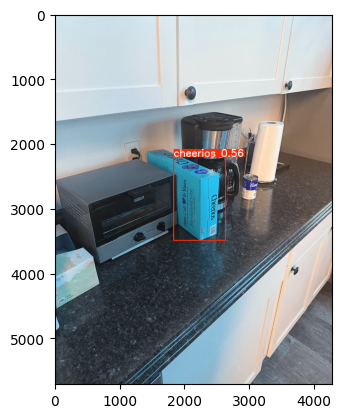

1


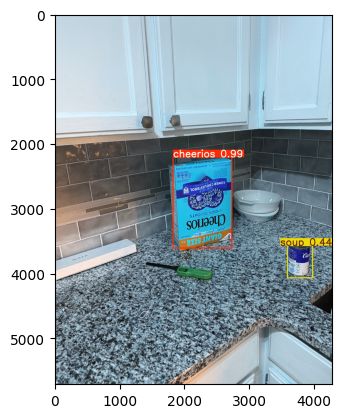

2


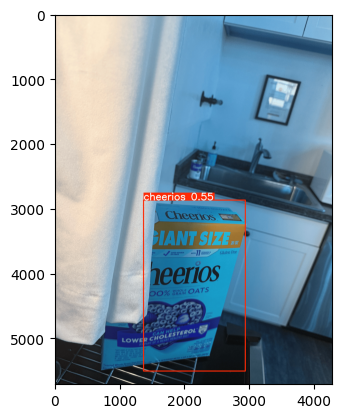

3


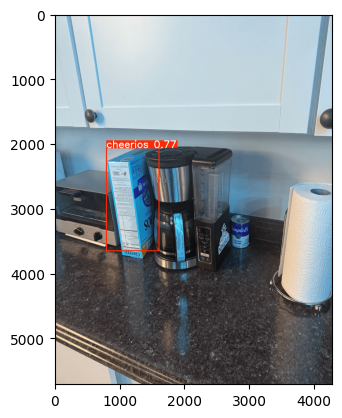

4


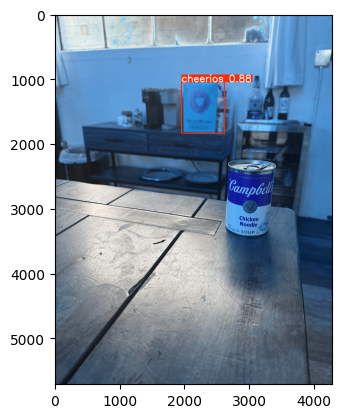

5


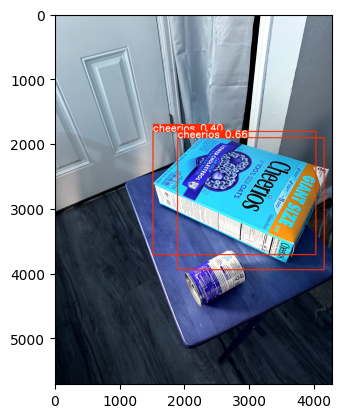

6


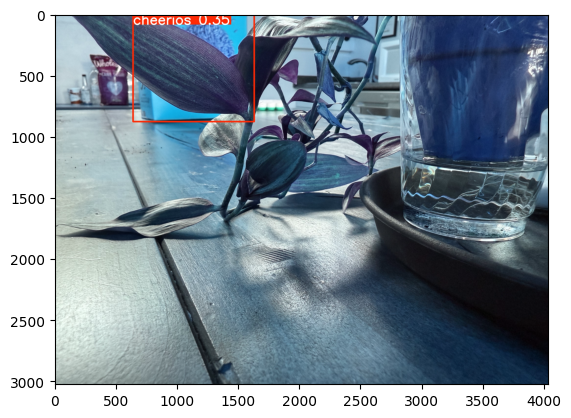

7


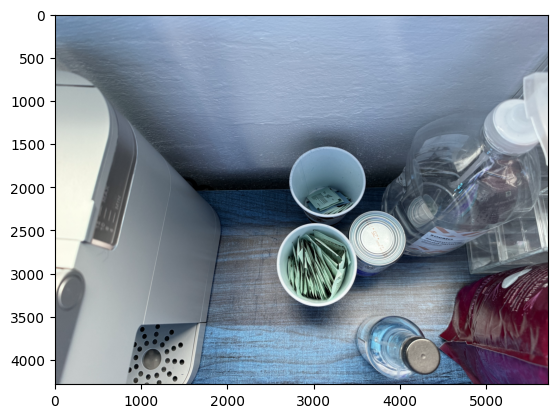

8


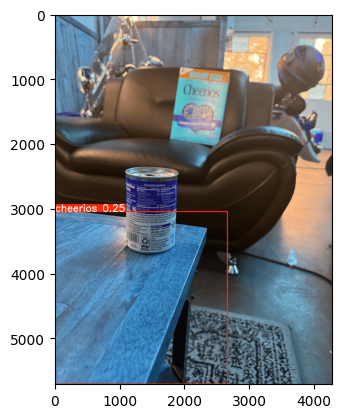

9


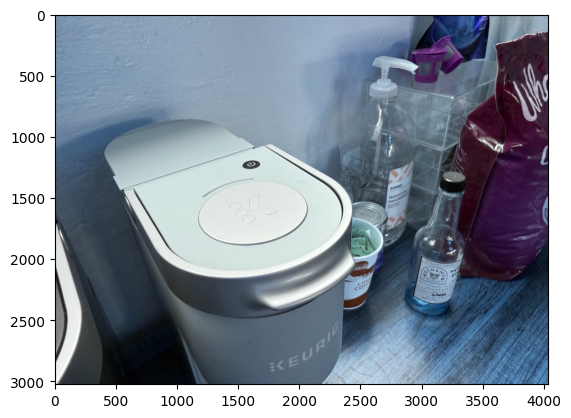

In [11]:
count = 0
for i in os.listdir('/kaggle/input/multi-class-object-detection-challenge/testImages/images'):
    img_path = f'/kaggle/input/multi-class-object-detection-challenge/testImages/images/{i}'
    results = model.predict(img_path, 
                            conf=0.3, device=-1, verbose=False) # 0 - GPU or "cpu" Image.fromarray(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2HSV))
    if count < 10:
        print(count)
        for result in model(img_path):
            #print(result)
            result.save(filename = f'image.jpg')
            plt.imshow(cv2.imread('image.jpg'))
            plt.show()
            count+=1
        
        
    output_txt = f"{output_dir}/{i.split('.')[0]}.txt"
    with open(output_txt, "w") as f:
        found = False
        for result in results:
            img_height, img_width = result.orig_shape
            boxes = result.boxes.data
            if boxes is None or len(boxes) == 0:
                continue
            filtered_boxes = boxes[boxes[:, 4] >= 0.05]
            if len(filtered_boxes) == 0:
                continue
            found = True
            for box in filtered_boxes:
                x1, y1, x2, y2, confidence, cls_id = box.tolist()

                x_center = ((x1 + x2) / 2) / img_width
                y_center = ((y1 + y2) / 2) / img_height
                width = (x2 - x1) / img_width
                height = (y2 - y1) / img_height

                f.write(f"0 {confidence:.6f} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        if not found:
            f.write("")

In [12]:
rows = []
output_dir = Path("/kaggle/working/predictions/labels")
TEST = Path('/kaggle/input/multi-class-object-detection-challenge/testImages/images')
test_imgs = {p.stem for p in TEST.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
predicted = set()

for file in output_dir.glob("*.txt"):
    name = file.stem
    predicted.add(name)

    try:
        lines = [l.strip() for l in open(file) if len(l.strip().split()) == 6]
    except:
        lines = []

    rows.append({"image_id": name, "prediction_string": " ".join(lines) if lines else "no boxes"})
for name in test_imgs - predicted:
    rows.append({"image_id": name, "prediction_string": "no boxes"})
    
rows = pandas.DataFrame(rows)
rows.to_csv("submission.csv", index=False)
rows

,image_id,prediction_string
0,IMG_8717,no boxes
1,IMG_8778,0 0.547327 0.501488 0.733851 0.366129 0.461984
2,IMG_8692,0 0.831837 0.120656 0.557143 0.241312 0.244371
3,IMG_9898,0 0.920495 0.620410 0.149460 0.432933 0.298921...
4,IMG_9172,0 0.845669 0.513932 0.533496 0.189249 0.279375
...,...,...
224,IMG_9166,0 0.961399 0.431525 0.617440 0.423492 0.229453
225,IMG_9926,0 0.517497 0.936683 0.073761 0.121229 0.144539...
226,IMG_9922,no boxes
227,IMG_8691,0 0.546322 0.071404 0.512333 0.142809 0.058383...
